<a href="https://colab.research.google.com/github/bnradon/AI-Product-Management-System/blob/main/Proyecto_Final_IA_KNN_Brayan_Brandon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final IA - Clasificador de Frutas con KNN

**Objetivo:** Desarrollar un sistema capaz de clasificar imágenes de frutas utilizando el algoritmo K-Nearest Neighbors (KNN).

### 1. Dataset
El dataset que utilizamos consiste en imágenes de 5 tipos de frutas: Banano, Mango, Manzana, Naranja y Sandía.

Las imágenes se redimension a 64x64 píxeles para que el modelo tenga mejor procesamiento.

### 2. Carga y Descompresión del Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
import glob
import random
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from google.colab import files

In [ ]:
uploaded = files.upload()

zip_path = 'dataset.zip'
extract_path = 'dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset descomprimido")


Saving dataset.zip to dataset (1).zip
Dataset descomprimido


Se redimensionan las imágenes

In [ ]:
IMG_SIZE = (64, 64)

In [ ]:
initial_contents = os.listdir(extract_path)

if len(initial_contents) == 1 and os.path.isdir(os.path.join(extract_path, initial_contents[0])):
    extract_path = os.path.join(extract_path, initial_contents[0])


In [ ]:
class_names = sorted([
    item.name for item in os.scandir(extract_path) if item.is_dir()
])

class_to_label = {name: i for i, name in enumerate(class_names)}

print("Clases:", class_names)

Clases: ['banano', 'mango', 'manzana', 'naranja', 'sandia']


In [ ]:
all_image_paths = []

for ext in ["*.png", "*.jpg", "*.jpeg"]:
    all_image_paths.extend(glob.glob(os.path.join(extract_path, "*", ext)))

random.seed(42)
random.shuffle(all_image_paths)

all_image_labels = [
    class_to_label[path.split(os.path.sep)[-2]]
    for path in all_image_paths
]

print("Imágenes:", len(all_image_paths))

Imágenes: 116


### 3. Preparación de los Datos (Pre-procesamiento)
las imágenes se transforman en vectores numéricos (aplanado), normalizamos los valores de los píxeles (escala 0-1) y dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%) para validar nuestro modelo.

In [ ]:
X = []
y = []

for path, label in zip(all_image_paths, all_image_labels):

    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)

    img_array = np.array(img).flatten()

    X.append(img_array)
    y.append(label)

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

print("Shape dataset:", X.shape)

Shape dataset: (116, 12288)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 92
Test: 24


### 4. Entrenamiento del Modelo
Utilizamos el algoritmo K-Nearest Neighbors (KNN). El modelo aprende a clasificar comparando las características de las nuevas imágenes con las más similares en el set de entrenamiento.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

### 5. Evaluación del Modelo
Se calcula el Accuracy final y genera visualizaciones para entender el desempeño que tuvo el modelo. Muestra tanto aciertos como errores cometidos

In [ ]:
# Realizar predicciones y calcular Accuracy
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Evaluación del Modelo")
print(f"Accuracy Final: {accuracy*100:.2f}%")

Evaluación del Modelo
Accuracy Final: 66.67%


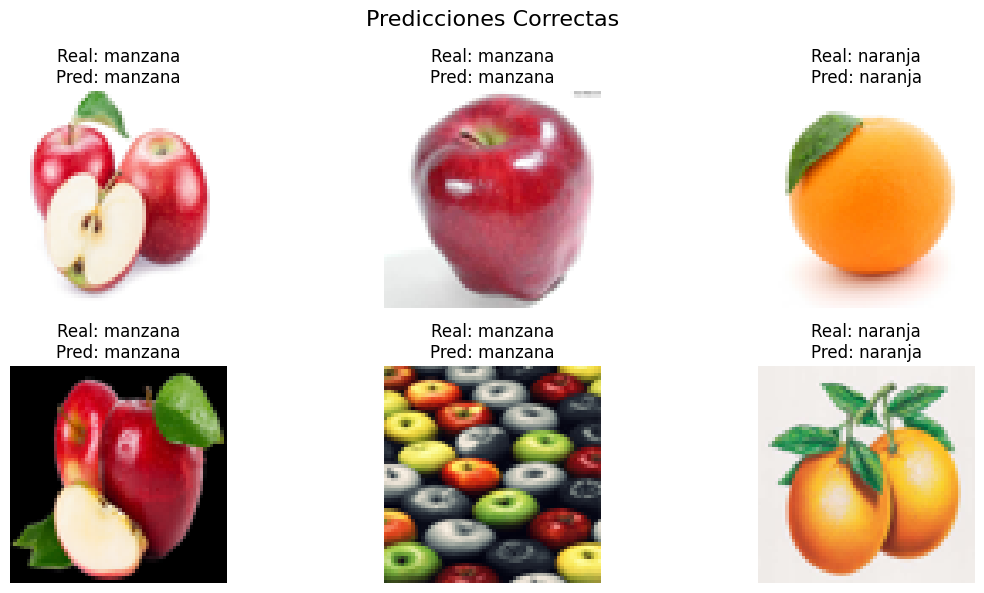

In [ ]:
# Predicciones CORRECTAS
correct_idx = np.where(y_pred == y_test)[0]
plt.figure(figsize=(12, 6))
plt.suptitle("Predicciones Correctas", fontsize=16)
for i, idx in enumerate(correct_idx[:6]):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_test[idx].reshape(64, 64, 3))
    plt.title(f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

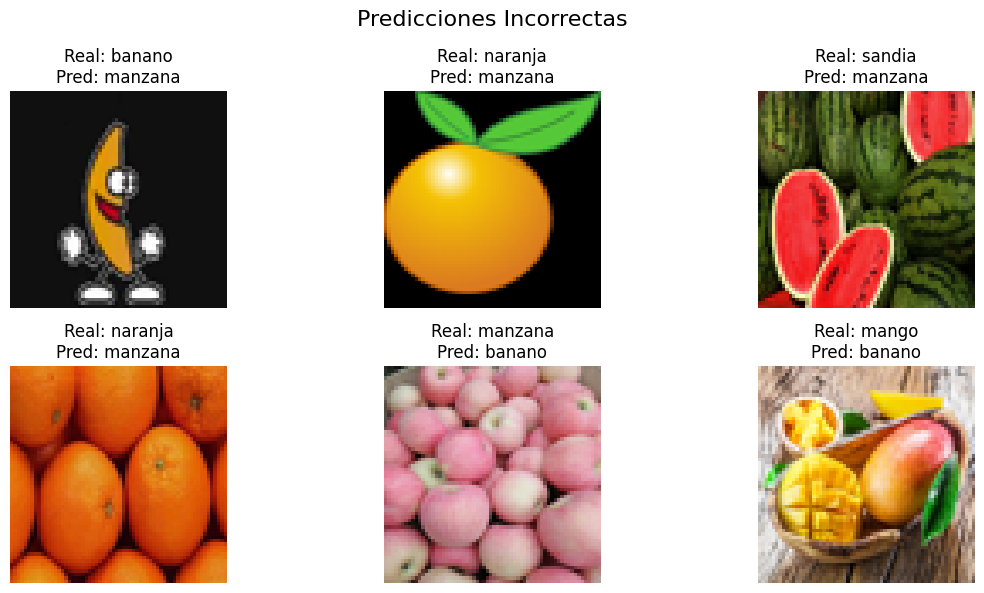

In [ ]:
# Predicciones INCORRECTAS
wrong_idx = np.where(y_pred != y_test)[0]
if len(wrong_idx) > 0:
    plt.figure(figsize=(12, 6))
    plt.suptitle("Predicciones Incorrectas", fontsize=16)
    for i, idx in enumerate(wrong_idx[:6]):
        plt.subplot(2, 3, i+1)
        plt.imshow(X_test[idx].reshape(64, 64, 3))
        plt.title(f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No hubo ninguna predicción incorrecta")

# Matriz de confusión

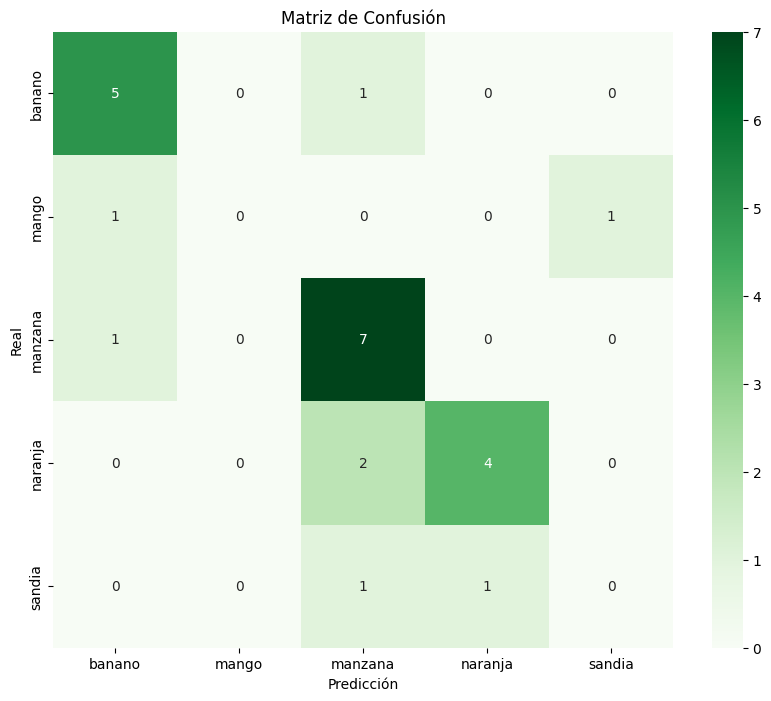


Reporte Detallado de Clasificación:
              precision    recall  f1-score   support

      banano       0.71      0.83      0.77         6
       mango       0.00      0.00      0.00         2
     manzana       0.64      0.88      0.74         8
     naranja       0.80      0.67      0.73         6
      sandia       0.00      0.00      0.00         2

    accuracy                           0.67        24
   macro avg       0.43      0.47      0.45        24
weighted avg       0.59      0.67      0.62        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

print("\nReporte Detallado de Clasificación:")
print(classification_report(y_test, y_pred, target_names=class_names))

### 6. Demo Funcional :)
Subimos una impagen totalmente nueva y se calcula la probabilidad de pertenencia a una de clases.

Saving images.jpg to images.jpg


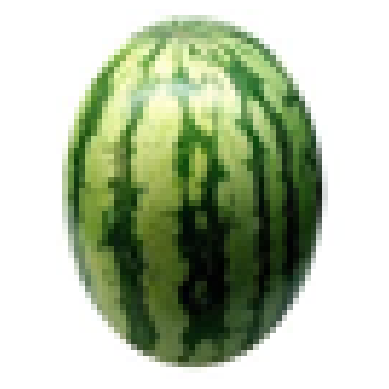


 Resultado de la Demo
Fruta: MANZANA
Confianza: 100.00%


In [ ]:
uploaded = files.upload()

if uploaded:
    img_path = list(uploaded.keys())[0]
    img = Image.open(img_path).convert("RGB")
    img = img.resize(IMG_SIZE)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    img_array = np.array(img).flatten() / 255.0

    # Probabilidad y clase
    proba = knn.predict_proba([img_array])
    prediction = knn.predict([img_array])
    confidence = np.max(proba) * 100

    print(f"\n Resultado de la Demo")
    print(f"Fruta: {class_names[prediction[0]].upper()}")
    print(f"Confianza: {confidence:.2f}%")